In [1]:
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import copy
import numpy as np
import seaborn as sns
import itertools
import ast
import scipy.stats as stats

from _helper_functions import cb

In [2]:
fn='reference-files/syntax-fam-Bin2Annotation.pydict.pickle'
with open(fn,'rb') as f:
    Bin2Annotation=pickle.load(f)

In [3]:
fn='reference-files//OLSName2SyntaxFamily-vary-aff.pydict.pickle'
with open(fn,'rb') as f:
    OLSName2SyntaxFamily=pickle.load(f)


In [4]:
fn='reference-files//OLSEnSeq2Name.pydict.pickle'
with open(fn,'rb') as f:
    OLSEnSeq2Name=pickle.load(f)


In [5]:
fn='reference-files//SyntaxFamily2OLSName-vary-aff.pydict.pickle'
with open(fn,'rb') as f:
    SyntaxFamily2OLSName=pickle.load(f)
    

In [6]:

fn='F03-Syntax-Families/syntax-family-analysis-table-with-permuted-data_numiters=100.pd.df.pickle'
sdf=pd.read_pickle(fn).set_index('syntax-family',drop=False)
sdf.loc[:,'n-func-inert-tuple']=sdf.loc[:,'n-func-inert-tuple'].apply(lambda i: ast.literal_eval(i)) # convert strings of tuples to literal tuples
sdf=sdf.loc[:,'n-func-inert-tuple']
sdf.head(1)

syntax-family
L1-GR-L2-EF-L3-EF-L4-GR-L5-GF-L6    (4, 2)
Name: n-func-inert-tuple, dtype: object

In [7]:
df=pd.read_pickle(f'01-Calculate-Enhancer-Activity-Levels/02-generated-tables//endf.rescaledPctl_45_85.wtcollapsed.sumRnaDivSumDna-repSum.pd.df.pickle')
df['n-func-inert-tuple']=df['enhancer-sites'].apply(lambda sites: sdf[OLSName2SyntaxFamily[sites]])
df['bin-annotation']=df['n-func-inert-tuple'].apply(lambda bi: Bin2Annotation[bi])
df.head(1)

,enhancer-id,enhancer-sites,wt-enhancer-seq,wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,abl-enhancer-seq,abl-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,act-change-bin,enhancer-dependent-gata-ets,n-func-inert-tuple,bin-annotation
0,Otx-a WT,L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6,CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATT...,1.197798,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,0.848065,"(1, 0)",0,"(4, 2)",Moderate


/tscc/nfs/home/solvason/miniconda/envs/notebook1/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/tscc/nfs/home/solvason/miniconda/envs/notebook1/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


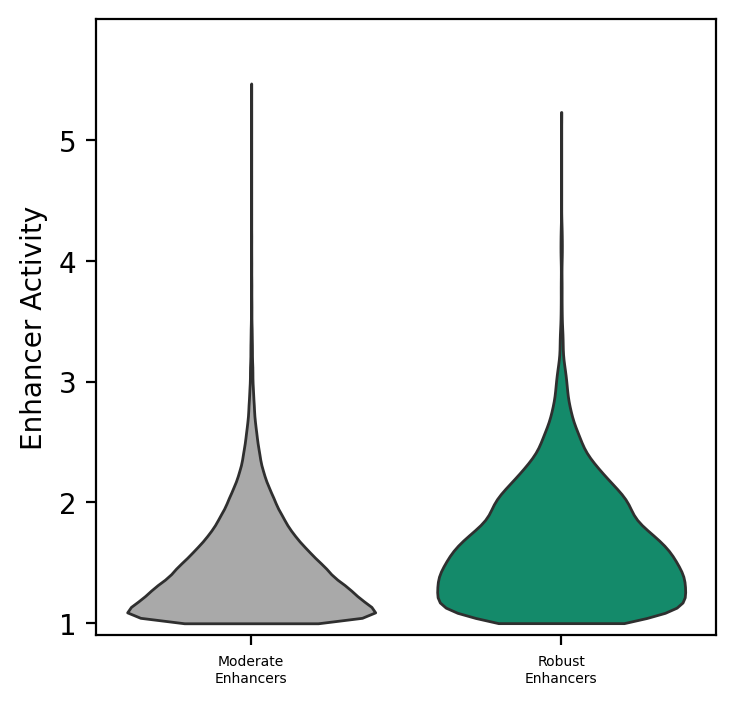

In [8]:
fig,ax=plt.subplots(1,figsize=(4,4),dpi=200)

groups=['Moderate','Robust']
palette=['darkgrey',cb['green']]
sns.violinplot(data=df.loc[df['wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled']>1,:],x='bin-annotation',y='wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled',cut=0,ax=ax,order=groups,palette=palette,inner=None,linewidth=1,scale='width')

ax.set_ylim(.9,6)

ax.set_xticks(range(len(groups)),groups,size=5)
ax.set_ylabel('activity')

ax.set_ylabel('Enhancer Activity')
ax.set_xlabel('')
ax.set_xticks([0,1],labels=['Moderate\nEnhancers','Robust\nEnhancers'])

ax.set_yticks([1,2,3,4,5])